# Customer Churn — Modeling and Evaluation

## Business objective
The goal of this notebook is to train and compare churn prediction models in order to identify customers at risk and support retention prioritization.

## Notebook objectives
This notebook focuses on:
1. training a baseline model and more advanced models,
2. handling class imbalance,
3. comparing model performance on validation data,
4. tuning the decision threshold,
5. evaluating the selected model on the held-out test set,
6. assessing the model as both a classifier and a ranking tool,
7. saving the final modeling artifact.

## Modeling requirements covered
This notebook compares three models:
- Logistic Regression (baseline),
- Random Forest,
- XGBoost.

It reports:
- ROC-AUC,
- PR-AUC,
- F1-score,
- Recall,
- Precision,
- Recall@Top10%.

It also tests imbalance-aware strategies through model weighting and threshold adjustment.

In [37]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
REPORTS_DIR = Path("../reports")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Load engineered datasets

This notebook reuses the engineered train / validation / test splits created in `02_feature_engineering.ipynb`.

In [38]:
train_df = pd.read_csv(DATA_DIR / "train_engineered.csv")
valid_df = pd.read_csv(DATA_DIR / "validation_engineered.csv")
test_df = pd.read_csv(DATA_DIR / "test_engineered.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (4929, 28)
Validation shape: (1057, 28)
Test shape: (1057, 28)


,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,tenure_group,long_contract,high_monthly_charges,avg_monthly_value_proxy,subscribed_services_count,payment_group,has_security_bundle,fiber_optic_customer,churn
0,Male,0,Yes,No,62,Yes,No,DSL,No,Yes,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),60.1500,"3,753.2000",long_term,1,0,60.5355,3,automatic,1,0,0
1,Female,0,Yes,Yes,60,No,No phone service,DSL,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,49.7500,"3,069.4500",long_term,0,0,51.1575,3,electronic_check,0,0,0
2,Male,0,No,No,53,Yes,No,DSL,No,No,Yes,No,No,Yes,One year,Yes,Electronic check,61.1000,"3,357.9000",long_term,1,0,63.3566,2,electronic_check,1,0,0
3,Female,1,Yes,No,43,No,No phone service,DSL,No,Yes,Yes,No,Yes,Yes,Month-to-month,No,Credit card (automatic),55.5500,"2,342.2000",long_term,0,0,54.4698,4,automatic,1,0,1
4,Female,0,No,No,72,Yes,No,DSL,Yes,Yes,Yes,Yes,No,Yes,Two year,Yes,Credit card (automatic),73.0000,"5,265.2000",long_term,1,1,73.1278,5,automatic,1,0,0


In [39]:
TARGET_COL = "churn"

X_train = train_df.drop(columns=[TARGET_COL]).copy()
y_train = train_df[TARGET_COL].copy()

X_valid = valid_df.drop(columns=[TARGET_COL]).copy()
y_valid = valid_df[TARGET_COL].copy()

X_test = test_df.drop(columns=[TARGET_COL]).copy()
y_test = test_df[TARGET_COL].copy()

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "| y_valid:", y_valid.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)

X_train: (4929, 27) | y_train: (4929,)
X_valid: (1057, 27) | y_valid: (1057,)
X_test : (1057, 27) | y_test : (1057,)


## 2. Check class balance

The churn target is moderately imbalanced, so model evaluation must go beyond accuracy.

In [40]:
split_balance = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(y_train), len(y_valid), len(y_test)],
        "positives": [int(y_train.sum()), int(y_valid.sum()), int(y_test.sum())],
        "negative": [int((1 - y_train).sum()), int((1 - y_valid).sum()), int((1 - y_test).sum())],
        "churn_rate": [y_train.mean(), y_valid.mean(), y_test.mean()],
    }
)

split_balance["churn_rate_pct"] = (split_balance["churn_rate"] * 100).round(2)
split_balance

,split,rows,positives,negative,churn_rate,churn_rate_pct
0,train,4929,1308,3621,0.2654,26.5400
1,validation,1057,281,776,0.2658,26.5800
2,test,1057,280,777,0.2649,26.4900


## 3. Define preprocessing

The same preprocessing logic as in the previous notebook is reused:
- median imputation for numeric variables,
- most-frequent imputation for categorical variables,
- scaling for numeric features,
- one-hot encoding for categorical features.

A fresh preprocessor is created inside each model pipeline to keep the workflow fully reproducible.

In [41]:
numeric_features = [
    "senior_citizen",
    "tenure",
    "monthly_charges",
    "total_charges",
    "avg_monthly_value_proxy",
    "subscribed_services_count",
    "long_contract",
    "high_monthly_charges",
    "has_security_bundle",
    "fiber_optic_customer",
]

categorical_features = [
    "gender",
    "partner",
    "dependents",
    "phone_service",
    "multiple_lines",
    "internet_service",
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies",
    "contract",
    "paperless_billing",
    "payment_method",
    "tenure_group",
    "payment_group",
]

unused_features = set(X_train.columns) - set(numeric_features) - set(categorical_features)
assert len(unused_features) == 0, f"Unassigned features found: {unused_features}"

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 10
Categorical features: 17


In [42]:
def make_preprocessor() -> ColumnTransformer:
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    return preprocessor

## 4. Define evaluation helpers

We use both ranking metrics and threshold-based classification metrics.

### Why these metrics?
- **ROC-AUC**: ranking quality across thresholds.
- **PR-AUC**: especially relevant for imbalanced classification.
- **Precision / Recall / F1**: operational trade-offs at a chosen threshold.
- **Recall@Top10%**: prioritization metric to measure how many churners are captured among the top-risk customers.

In [43]:
def recall_at_top_k(y_true, y_score, top_fraction: float = 0.10) -> float:
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    n_top = max(1, int(np.ceil(len(y_score) * top_fraction)))
    top_indices = np.argsort(y_score)[::-1][:n_top]

    positives_in_top = y_true[top_indices].sum()
    total_positives = y_true.sum()

    if total_positives == 0:
        return np.nan

    return positives_in_top / total_positives


def compute_classification_metrics(y_true, y_score, threshold: float = 0.50) -> dict:
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    y_pred = (y_score >= threshold).astype(int)

    return {
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "recall_at_top10pct": recall_at_top_k(y_true, y_score, top_fraction=0.10),
        "predicted_positive_rate": y_pred.mean(),
    }


def threshold_sweep(y_true, y_score, thresholds=None) -> pd.DataFrame:
    if thresholds is None:
        thresholds = np.arange(0.20, 0.81, 0.02)

    rows = []
    for threshold in thresholds:
        metrics = compute_classification_metrics(y_true, y_score, threshold=threshold)
        rows.append(
            {
                "threshold": metrics["threshold"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "predicted_positive_rate": metrics["predicted_positive_rate"],
            }
        )

    return pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)

## 5. Define the models

Three models are trained:

- **Logistic Regression** as a baseline,
- **Random Forest** as a bagging tree model,
- **XGBoost** as a gradient boosting model.

Imbalance handling:
- `class_weight="balanced"` for Logistic Regression,
- `class_weight="balanced_subsample"` for Random Forest,
- `scale_pos_weight` for XGBoost.

In [44]:
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Negative / positive ratio in training data: {neg_pos_ratio:.3f}")

Negative / positive ratio in training data: 2.768


In [45]:
def build_model_pipelines(class_ratio: float) -> dict:
    model_pipelines = {
        "Logistic Regression": Pipeline(
            steps=[
                ("preprocessor", make_preprocessor()),
                (
                    "model",
                    LogisticRegression(
                        max_iter=2000,
                        class_weight="balanced",
                        solver="liblinear",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "Random Forest": Pipeline(
            steps=[
                ("preprocessor", make_preprocessor()),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=400,
                        min_samples_leaf=3,
                        class_weight="balanced_subsample",
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "XGBoost": Pipeline(
            steps=[
                ("preprocessor", make_preprocessor()),
                (
                    "model",
                    XGBClassifier(
                        objective="binary:logistic",
                        eval_metric="logloss",
                        n_estimators=300,
                        learning_rate=0.05,
                        max_depth=4,
                        min_child_weight=2,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        reg_lambda=1.0,
                        scale_pos_weight=class_ratio,
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                        tree_method="hist",
                        verbosity=0,
                    ),
                ),
            ]
        ),
    }

    return model_pipelines

## 6. Train models and evaluate on validation data

The initial comparison is done on the validation set at the default threshold of 0.50.

In [46]:
pipelines = build_model_pipelines(neg_pos_ratio)

fitted_pipelines = {}
validation_probabilities = {}
validation_rows = []

for model_name, pipeline in pipelines.items():
    print(f"Training {model_name}...")
    pipeline.fit(X_train, y_train)

    y_valid_score = pipeline.predict_proba(X_valid)[:, 1]

    fitted_pipelines[model_name] = pipeline
    validation_probabilities[model_name] = y_valid_score

    metrics = compute_classification_metrics(y_valid, y_valid_score, threshold=0.50)
    metrics["model"] = model_name
    validation_rows.append(metrics)

validation_results = (
    pd.DataFrame(validation_rows)
    .sort_values(["pr_auc", "recall_at_top10pct", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)


Training Logistic Regression...
Training Random Forest...
Training XGBoost...


In [47]:
validation_results_display = validation_results.copy()

metric_cols = [
    "roc_auc",
    "pr_auc",
    "precision",
    "recall",
    "f1",
    "recall_at_top10pct",
    "predicted_positive_rate",
]

validation_results_display[metric_cols] = validation_results_display[metric_cols].round(4)
validation_results_display

,threshold,roc_auc,pr_auc,precision,recall,f1,recall_at_top10pct,predicted_positive_rate,model
0,0.5000,0.8322,0.6413,0.5264,0.7438,0.6165,0.2883,0.3756,XGBoost
1,0.5000,0.8322,0.6379,0.5179,0.7722,0.6200,0.2811,0.3964,Logistic Regression
2,0.5000,0.8323,0.6281,0.5937,0.6655,0.6275,0.2847,0.2980,Random Forest


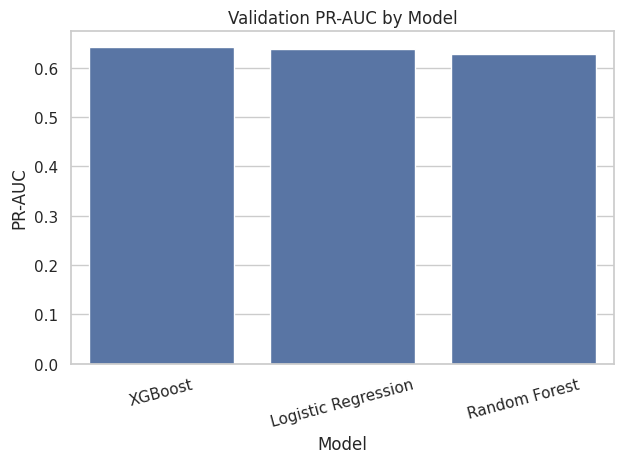

In [48]:
ax = sns.barplot(
    data=validation_results.sort_values("pr_auc", ascending=False),
    x="model",
    y="pr_auc"
)
ax.set_title("Validation PR-AUC by Model")
ax.set_xlabel("Model")
ax.set_ylabel("PR-AUC")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 7. Select the best model

Model selection is primarily based on validation PR-AUC, since churn prediction is an imbalanced classification problem and correctly ranking likely churners is important for business prioritization.

On the validation set:
- XGBoost achieved the best PR-AUC (0.6413),
- Logistic Regression was very close (0.6379),
- Random Forest ranked slightly lower (0.6281).

In [49]:
best_model_name = validation_results.iloc[0]["model"]
best_validation_score = validation_probabilities[best_model_name]

print(f"Selected model based on validation performance: {best_model_name}")

Selected model based on validation performance: XGBoost


XGBoost was selected as the final model because it achieved the best validation PR-AUC (0.6413), while also delivering competitive ROC-AUC (0.8322) and strong Recall@Top10% (0.2883).

The performance gap with Logistic Regression is relatively small, which is itself an interesting result: a simpler linear baseline already performs well on this dataset. However, XGBoost remains the strongest candidate overall and is therefore retained as the final model.

## 8. Tune the decision threshold on validation data

The default threshold of 0.50 is not necessarily optimal for churn use cases.
A lower or higher threshold may improve the precision / recall balance.

We select the threshold that maximizes **validation F1-score**, then compare it with the default threshold.

In [50]:
threshold_results = threshold_sweep(y_valid, best_validation_score)
threshold_results.head(10)

,threshold,precision,recall,f1,predicted_positive_rate
0,0.5200,0.5393,0.7331,0.6214,0.3614
1,0.5400,0.5492,0.7153,0.6213,0.3463
2,0.4800,0.5246,0.7580,0.6201,0.3841
3,0.4600,0.5167,0.7722,0.6191,0.3974
4,0.5000,0.5264,0.7438,0.6165,0.3756
5,0.5600,0.5540,0.6940,0.6161,0.3330
6,0.4400,0.5045,0.7900,0.6158,0.4163
7,0.4200,0.4978,0.8043,0.6150,0.4295
8,0.6000,0.5741,0.6619,0.6149,0.3065
9,0.5800,0.5621,0.6762,0.6139,0.3198


In [51]:
best_threshold = float(threshold_results.iloc[0]["threshold"])
print(f"Best threshold on validation set (max F1): {best_threshold:.2f}")

Best threshold on validation set (max F1): 0.52


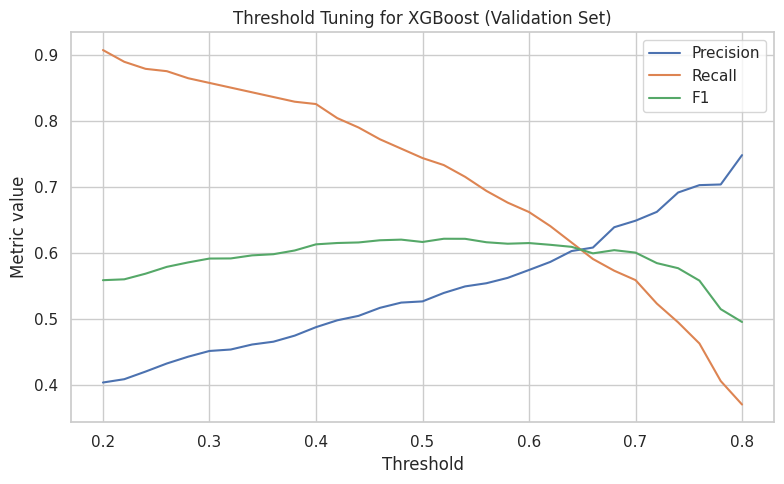

In [52]:
threshold_plot_df = threshold_results.sort_values("threshold")

plt.figure(figsize=(8, 5))
plt.plot(threshold_plot_df["threshold"], threshold_plot_df["precision"], label="Precision")
plt.plot(threshold_plot_df["threshold"], threshold_plot_df["recall"], label="Recall")
plt.plot(threshold_plot_df["threshold"], threshold_plot_df["f1"], label="F1")
plt.title(f"Threshold Tuning for {best_model_name} (Validation Set)")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
validation_default = compute_classification_metrics(y_valid, best_validation_score, threshold=0.50)
validation_tuned = compute_classification_metrics(y_valid, best_validation_score, threshold=best_threshold)

validation_threshold_comparison = pd.DataFrame(
    [
        {"setting": "default_0.50", **validation_default},
        {"setting": f"tuned_{best_threshold:.2f}", **validation_tuned},
    ]
)

validation_threshold_comparison.round(4)

,setting,threshold,roc_auc,pr_auc,precision,recall,f1,recall_at_top10pct,predicted_positive_rate
0,default_0.50,0.5000,0.8322,0.6413,0.5264,0.7438,0.6165,0.2883,0.3756
1,tuned_0.52,0.5200,0.8322,0.6413,0.5393,0.7331,0.6214,0.2883,0.3614


## 9. Refit the selected model on train + validation

After selecting:
- the best model architecture,
- and the operating threshold,

we refit the model on the combined train + validation data, then evaluate once on the untouched test set.

In [54]:
X_train_full = pd.concat([X_train, X_valid], axis=0).reset_index(drop=True)
y_train_full = pd.concat([y_train, y_valid], axis=0).reset_index(drop=True)

print("Full training set shape:", X_train_full.shape, y_train_full.shape)

Full training set shape: (5986, 27) (5986,)


In [55]:
final_pipeline = clone(fitted_pipelines[best_model_name])
final_pipeline.fit(X_train_full, y_train_full)

y_test_score = final_pipeline.predict_proba(X_test)[:, 1]

## 10. Final evaluation on the test set

We report the required classification metrics on the held-out test set:
- ROC-AUC,
- PR-AUC,
- Precision,
- Recall,
- F1-score,
- Recall@Top10%.

We compare:
- the default threshold of 0.50,
- the tuned threshold selected on validation data.

In [56]:
test_default_metrics = compute_classification_metrics(y_test, y_test_score, threshold=0.50)
test_tuned_metrics = compute_classification_metrics(y_test, y_test_score, threshold=best_threshold)

test_results = pd.DataFrame(
    [
        {"setting": "default_0.50", **test_default_metrics},
        {"setting": f"tuned_{best_threshold:.2f}", **test_tuned_metrics},
    ]
)

test_results.round(4)

,setting,threshold,roc_auc,pr_auc,precision,recall,f1,recall_at_top10pct,predicted_positive_rate
0,default_0.50,0.5000,0.8482,0.6519,0.5274,0.7893,0.6323,0.2750,0.3964
1,tuned_0.52,0.5200,0.8482,0.6519,0.5338,0.7607,0.6274,0.2750,0.3775


In [57]:
final_test_row = test_results.sort_values("f1", ascending=False).iloc[0]
final_test_row

setting                    default_0.50
threshold                        0.5000
roc_auc                          0.8482
pr_auc                           0.6519
precision                        0.5274
recall                           0.7893
f1                               0.6323
recall_at_top10pct               0.2750
predicted_positive_rate          0.3964
Name: 0, dtype: object

### - Threshold interpretation

Threshold tuning was performed on the validation set, where a threshold of 0.52 slightly improved F1-score compared with the default threshold of 0.50.

However, on the held-out test set, the default threshold of 0.50 remained slightly stronger in terms of F1-score (0.6323 vs. 0.6274). This suggests that the gain from threshold tuning is limited and may not generalize consistently.

In practice, this means that threshold choice should depend on business priorities. If the objective is to keep a simple and standard operating point, 0.50 remains a reasonable default. If the objective is to fine-tune the precision/recall trade-off, threshold optimization can still be useful.

### - Recall@Top10%

In [58]:
top_10_recall = test_default_metrics["recall_at_top10pct"]
random_baseline = 0.10
lift_at_10 = top_10_recall / random_baseline

pd.DataFrame(
    {
        "metric": ["Recall@Top10%", "Random baseline", "Lift@Top10%"],
        "value": [top_10_recall, random_baseline, lift_at_10],
    }
).round(4)

,metric,value
0,Recall@Top10%,0.2750
1,Random baseline,0.1000
2,Lift@Top10%,2.7500


Among the top 10% highest-risk customers ranked by the model, the model captures 27.5% of all churners in the test set.

This corresponds to a lift of 2.75x compared with random targeting, which would capture only 10% of churners on average. This confirms that the model is useful not only as a classifier, but also as a prioritization tool for retention campaigns.

### - Decile analysis:

In [59]:
test_scored = X_test.copy()
test_scored["churn"] = y_test.values
test_scored["score"] = y_test_score

test_scored["risk_decile"] = pd.qcut(
    test_scored["score"].rank(method="first"),
    10,
    labels=[f"D{i}" for i in range(1, 11)]
)

decile_summary = (
    test_scored.groupby("risk_decile", observed=False)
    .agg(
        customers=("churn", "size"),
        churn_rate=("churn", "mean"),
        min_score=("score", "min"),
        max_score=("score", "max"),
    )
    .sort_index(ascending=False)
    .reset_index()
)

decile_summary["churn_rate_pct"] = (decile_summary["churn_rate"] * 100).round(2)
decile_summary

,risk_decile,customers,churn_rate,min_score,max_score,churn_rate_pct
0,D10,106,0.7264,0.8426,0.9752,72.6400
1,D9,106,0.6415,0.7251,0.8420,64.1500
2,D8,105,0.3429,0.6241,0.7243,34.2900
3,D7,106,0.3868,0.4975,0.6240,38.6800
4,D6,105,0.2476,0.3397,0.4974,24.7600
5,D5,106,0.1415,0.2153,0.3388,14.1500
6,D4,106,0.1132,0.1135,0.2139,11.3200
7,D3,105,0.0190,0.0497,0.1132,1.9000
8,D2,106,0.0283,0.0233,0.0497,2.8300
9,D1,106,0.0000,0.0020,0.0230,0.0000


The decile analysis shows how churn risk concentrates in the highest-score groups. This is particularly useful for retention use cases, where actions are often limited to a fraction of the customer base.

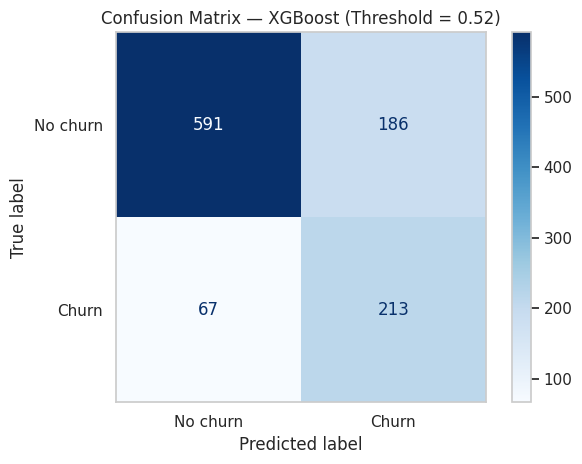

In [60]:
y_test_pred_tuned = (y_test_score >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_test_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No churn", "Churn"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name} (Threshold = {best_threshold:.2f})")
plt.grid(False)
plt.tight_layout()
plt.show()

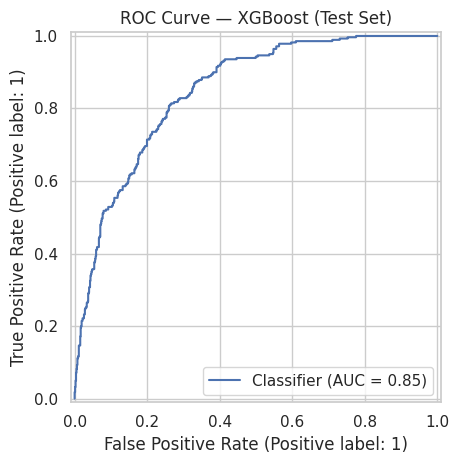

In [61]:
RocCurveDisplay.from_predictions(y_test, y_test_score)
plt.title(f"ROC Curve — {best_model_name} (Test Set)")
plt.tight_layout()
plt.show()

The selected XGBoost model is refit on the combined train + validation data and evaluated once on the untouched test set.

The final test evaluation confirms strong ranking performance:
- ROC-AUC: 0.8482
- PR-AUC: 0.6519

At the default threshold of 0.50, the model achieves:
- Precision: 0.5274
- Recall: 0.7893
- F1-score: 0.6323
- Recall@Top10%: 0.2750

These results indicate that the model is effective both for binary churn prediction and for prioritizing high-risk customers.

## 11. Prepare feature importance inputs for the explainability notebook

The final explainability notebook will use:
- model coefficients if the final model is logistic regression,
- feature importances if the final model is tree-based,
- SHAP if possible.

Here we extract the transformed feature names and produce a first importance table.

In [62]:
fitted_preprocessor = final_pipeline.named_steps["preprocessor"]
fitted_model = final_pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

if hasattr(fitted_model, "feature_importances_"):
    importance_values = fitted_model.feature_importances_
    importance_label = "importance"
elif hasattr(fitted_model, "coef_"):
    importance_values = np.abs(fitted_model.coef_[0])
    importance_label = "abs_coefficient"
else:
    importance_values = np.zeros(len(feature_names))
    importance_label = "importance"

feature_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        importance_label: importance_values,
    }
).sort_values(importance_label, ascending=False)

feature_importance_df["feature_group"] = feature_importance_df["feature"].str.split("__").str[0]

feature_importance_df.head(15)

,feature,importance,feature_group
6,num__long_contract,0.2606,num
42,cat__contract_Month-to-month,0.1544,cat
22,cat__internet_service_Fiber optic,0.0953,cat
9,num__fiber_optic_customer,0.0509,num
33,cat__tech_support_No,0.0482,cat
53,cat__tenure_group_new,0.0305,cat
24,cat__online_security_No,0.0264,cat
41,cat__streaming_movies_Yes,0.0203,cat
44,cat__contract_Two year,0.0183,cat
51,cat__tenure_group_long_term,0.0147,cat


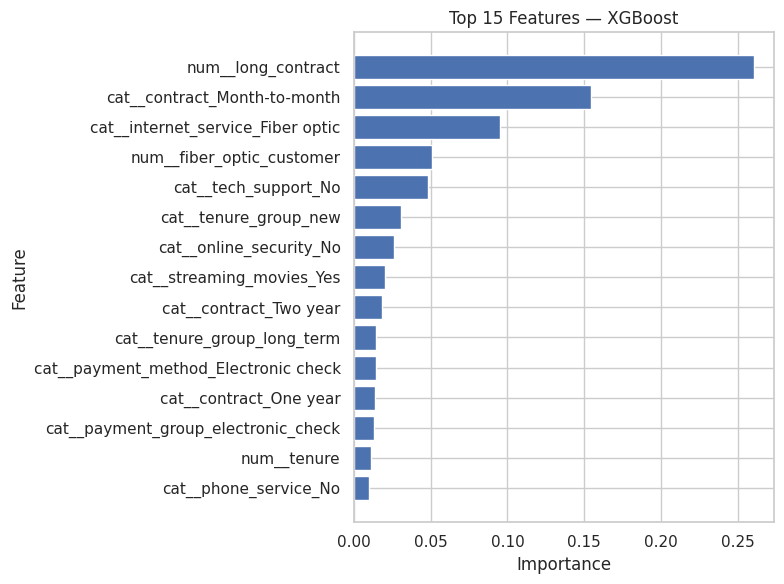

In [63]:
top_n = 15
plot_df = feature_importance_df.head(top_n).sort_values(by=importance_label, ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df[importance_label])
plt.title(f"Top {top_n} Features — {best_model_name}")
plt.xlabel(importance_label.replace("_", " ").title())
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 12. Save modeling artifacts

The following artifacts are saved:
- the final fitted pipeline,
- the selected model name,
- the threshold selected on the validation set,
- the feature names after preprocessing,
- the validation comparison table,
- the threshold tuning table,
- the final test metrics table.

These files will be reused in the explainability notebook and later in scripts / app integration.

In [64]:
artifact = {
    "pipeline": final_pipeline,
    "model_name": best_model_name,
    "threshold": best_threshold,
    "feature_names": list(feature_names),
    "validation_results": validation_results,
    "threshold_results": threshold_results,
    "test_results": test_results,
}

joblib.dump(artifact, MODELS_DIR / "final_model_artifact.joblib")

validation_results.to_csv(REPORTS_DIR / "validation_model_comparison.csv", index=False)
threshold_results.to_csv(REPORTS_DIR / "validation_threshold_tuning.csv", index=False)
test_results.to_csv(REPORTS_DIR / "test_final_model_metrics.csv", index=False)
feature_importance_df.to_csv(REPORTS_DIR / "feature_importance_preview.csv", index=False)

print("Saved files:")
print("-", MODELS_DIR / "final_model_artifact.joblib")
print("-", REPORTS_DIR / "validation_model_comparison.csv")
print("-", REPORTS_DIR / "validation_threshold_tuning.csv")
print("-", REPORTS_DIR / "test_final_model_metrics.csv")
print("-", REPORTS_DIR / "feature_importance_preview.csv")

Saved files:
- ../models/final_model_artifact.joblib
- ../reports/validation_model_comparison.csv
- ../reports/validation_threshold_tuning.csv
- ../reports/test_final_model_metrics.csv
- ../reports/feature_importance_preview.csv


## 13. Key takeaways

### Main outcomes
1. Three models were compared: Logistic Regression, Random Forest, and XGBoost.
2. XGBoost achieved the best validation PR-AUC (0.6413) and was selected as the final model.
3. On the test set, the final model reached a ROC-AUC of 0.8482 and a PR-AUC of 0.6519.
4. At the default threshold of 0.50, the model achieved an F1-score of 0.6323 and a Recall of 0.7893.
5. The model captured 27.5% of churners within the top 10% highest-risk customers, confirming its usefulness for prioritization.
6. Threshold tuning slightly improved validation F1-score at 0.52, but this gain did not persist on the test set.

### Business perspective
The model is useful not only as a binary classifier, but also as a ranking tool for retention targeting. In practice, it can help prioritize a limited group of customers for proactive churn prevention actions.

### Limitations
Some engineered features are partly redundant with original variables, such as:
- `long_contract` and `contract`
- `fiber_optic_customer` and `internet_service`
- `payment_group` and `payment_method`
- `tenure_group` and `tenure`

This is acceptable for predictive performance, but it should be considered carefully in the explainability phase.

### Next step
The next notebook will focus on explainability:
- global feature importance,
- SHAP analysis,
- interpretation of the main churn drivers,
- identification of the most sensitive customer profiles.